In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

gxl    = pd.read_csv("../data/gxl_ratios.csv")
dcf_df = pd.read_csv("../data/dcf_results.csv")
fin_df = pd.read_csv("../data/financials.csv")

print("Datos cargados OK")

Datos cargados OK


In [2]:
# Framework de riesgo para due diligence M&A
# Cada dimensión scored 1-5 (5 = mayor riesgo)

risk_assessment = {
    "Financial Risk": {
        "Leverage (Net Debt/EBITDA 2.85x)":     3,
        "Capex intensity (14.5% of revenue)":   3,
        "Interest coverage ratio":               2,
        "Free cash flow conversion":             2,
    },
    "Strategic Risk": {
        "Transformation execution risk":         3,
        "Customer concentration":                2,
        "Competition from Asian manufacturers":  3,
        "Technology disruption (pharma)":        2,
    },
    "Market Risk": {
        "EUR/USD FX exposure":                   3,
        "Raw material price volatility":         3,
        "Pharma R&D spending dependency":        2,
        "Regulatory risk (EU/FDA)":              2,
    },
    "Latam Risk": {
        "Brazil operations exposure":            2,
        "Mexico operations exposure":            2,
        "Argentina macro risk (indirect)":       4,
        "EM currency risk":                      3,
    }
}

# Calcular scores por categoría
risk_scores = {}
all_risks   = []

for category, risks in risk_assessment.items():
    scores = list(risks.values())
    avg    = round(np.mean(scores), 2)
    risk_scores[category] = avg
    for risk, score in risks.items():
        all_risks.append({
            "category": category,
            "risk":     risk,
            "score":    score
        })

risk_df = pd.DataFrame(all_risks)

print("Risk Scores by Category:")
for cat, score in risk_scores.items():
    level = "HIGH" if score >= 3.5 else "MEDIUM" if score >= 2.5 else "LOW"
    print(f"  {cat:<25} {score:.2f}/5.00  [{level}]")

overall_risk = round(np.mean(list(risk_scores.values())), 2)
print(f"\n  Overall Risk Score:       {overall_risk:.2f}/5.00")

Risk Scores by Category:
  Financial Risk            2.50/5.00  [MEDIUM]
  Strategic Risk            2.50/5.00  [MEDIUM]
  Market Risk               2.50/5.00  [MEDIUM]
  Latam Risk                2.75/5.00  [MEDIUM]

  Overall Risk Score:       2.56/5.00


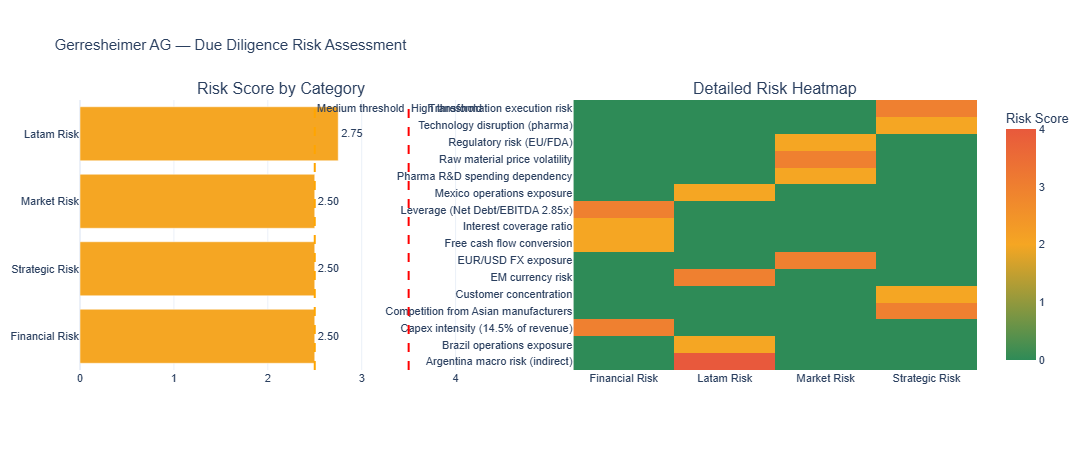

In [3]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=(
        "Risk Score by Category",
        "Detailed Risk Heatmap"
    ))

# Bar chart por categoría
categories  = list(risk_scores.keys())
scores      = list(risk_scores.values())
bar_colors  = ["#E8593C" if s >= 3.5 else "#F5A623" if s >= 2.5 else "#2E8B57"
               for s in scores]

fig.add_trace(go.Bar(
    x=scores,
    y=categories,
    orientation="h",
    marker_color=bar_colors,
    showlegend=False,
    text=[f"{s:.2f}" for s in scores],
    textposition="outside"
), row=1, col=1)

fig.add_vline(x=2.5, line_dash="dash", line_color="orange",
              annotation_text="Medium threshold", row=1, col=1)
fig.add_vline(x=3.5, line_dash="dash", line_color="red",
              annotation_text="High threshold", row=1, col=1)

# Heatmap detallado
pivot = risk_df.pivot_table(
    index="risk", columns="category", values="score"
).fillna(0)

fig.add_trace(go.Heatmap(
    z=pivot.values,
    x=pivot.columns.tolist(),
    y=pivot.index.tolist(),
    colorscale=[[0, "#2E8B57"], [0.5, "#F5A623"], [1, "#E8593C"]],
    showscale=True,
    colorbar=dict(title="Risk Score")
), row=1, col=2)

fig.update_layout(
    title="Gerresheimer AG — Due Diligence Risk Assessment",
    template="plotly_white",
    font=dict(family="Arial", size=11),
    height=450
)

fig.show()

In [4]:
# Conectar con risk index del proyecto Argentina vs Germany
latam_risk = pd.DataFrame({
    "country":        ["Brazil",  "Mexico",  "Argentina"],
    "risk_index_2023":[28.0,       18.0,      75.0],
    "gxl_exposure":   ["Medium",   "Low",     "Indirect"],
    "revenue_est_pct":[4.5,        2.5,       0.5],
})

latam_risk["revenue_at_risk_mn"] = (
    latam_risk["revenue_est_pct"] / 100 * 1969
).round(0)

latam_risk["risk_adjusted_exposure"] = (
    latam_risk["revenue_at_risk_mn"] *
    latam_risk["risk_index_2023"] / 100
).round(1)

print("Gerresheimer Latam Exposure — Risk Adjusted:")
print(latam_risk.to_string(index=False))
print(f"\nTotal Latam revenue at risk: EUR {latam_risk['revenue_at_risk_mn'].sum():.0f}mn")
print(f"Risk-adjusted exposure:      EUR {latam_risk['risk_adjusted_exposure'].sum():.1f}mn")
print(f"As % of total revenue:       {latam_risk['risk_adjusted_exposure'].sum()/1969*100:.1f}%")

Gerresheimer Latam Exposure — Risk Adjusted:
  country  risk_index_2023 gxl_exposure  revenue_est_pct  revenue_at_risk_mn  risk_adjusted_exposure
   Brazil             28.0       Medium              4.5                89.0                    24.9
   Mexico             18.0          Low              2.5                49.0                     8.8
Argentina             75.0     Indirect              0.5                10.0                     7.5

Total Latam revenue at risk: EUR 148mn
Risk-adjusted exposure:      EUR 41.2mn
As % of total revenue:       2.1%


In [5]:
# Sensibilidad del precio por acción a WACC y terminal growth
waccs   = [0.075, 0.080, 0.085, 0.090, 0.095]
tgrowths= [0.015, 0.020, 0.025, 0.030, 0.035]

latest_revenue = gxl.iloc[-1]["revenue"]
net_debt       = gxl.iloc[-1]["net_debt"]
shares_out     = 33.3

sensitivity_matrix = []

for wacc in waccs:
    row = []
    for tg in tgrowths:
        rev  = latest_revenue
        fcfs = []
        for _ in range(1, 6):
            rev    = rev * 1.07
            ebitda = rev * 0.26
            capex  = rev * 0.13
            ebit   = ebitda * 0.65
            nopat  = ebit * 0.72
            da     = ebitda - ebit
            fcf    = nopat + da - capex
            fcfs.append(fcf)

        tv   = fcfs[-1] * (1 + tg) / (wacc - tg)
        pv   = sum([f / (1+wacc)**i for i, f in enumerate(fcfs, 1)])
        ptv  = tv / (1+wacc)**5
        ev   = pv + ptv
        price= (ev - net_debt) / shares_out
        row.append(round(price, 1))
    sensitivity_matrix.append(row)

sens_df = pd.DataFrame(
    sensitivity_matrix,
    index=[f"WACC {w*100:.1f}%" for w in waccs],
    columns=[f"TG {t*100:.1f}%" for t in tgrowths]
)

print("Price per Share Sensitivity (Base Case Revenue CAGR 7%):")
print(sens_df.to_string())

Price per Share Sensitivity (Base Case Revenue CAGR 7%):
           TG 1.5%  TG 2.0%  TG 2.5%  TG 3.0%  TG 3.5%
WACC 7.5%     62.3     70.0     79.4     90.8    105.0
WACC 8.0%     54.0     60.5     68.1     77.3     88.5
WACC 8.5%     46.9     52.4     58.7     66.2     75.2
WACC 9.0%     40.8     45.4     50.8     57.0     64.4
WACC 9.5%     35.4     39.4     44.0     49.2     55.3


In [6]:
latam_risk.to_csv("../data/latam_risk_exposure.csv", index=False)
sens_df.to_csv("../data/sensitivity_analysis.csv")

print("Guardado OK")

Guardado OK
